---
### 🏥 Insurance Charges — Regresión Log-Lineal

Predicción de costos médicos (`charges`) a partir de variables demográficas y de salud (edad, sexo, BMI, hijos, tabaquismo, región).

**Enfoque**: dado que `charges` está fuertemente sesgada a la derecha, se entrena una regresión lineal sobre `log(charges)` en lugar de sobre la variable original, y luego se revierte la transformación para evaluar el error en dólares.

**Contenido del notebook**:
1. Carga y exploración inicial de los datos
2. Análisis de la distribución del target y justificación de la transformación logarítmica
3. Preprocesamiento (encoding de variables categóricas)
4. Entrenamiento del modelo
5. Evaluación en escala logarítmica y en escala dólar
6. Conclusiones

---


## 1. Carga y exploración inicial

Se importan las librerías necesarias y se carga `insurance.csv`. `df.info()` y `df.head()` permiten confirmar tipos de datos y verificar que no haya valores nulos antes de continuar.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración visual para Seaborn
sns.set_theme(style="whitegrid")

# Cargar el dataset
df = pd.read_csv('insurance.csv')

# Inspección inicial
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Distribución de la variable objetivo

Se visualiza el histograma de `charges` y se calcula su *skewness* (asimetría). Un valor de skew claramente mayor a 0 indica una distribución con cola larga hacia la derecha (pocos pacientes con costos muy altos), lo cual motiva la transformación que se aplica a continuación.

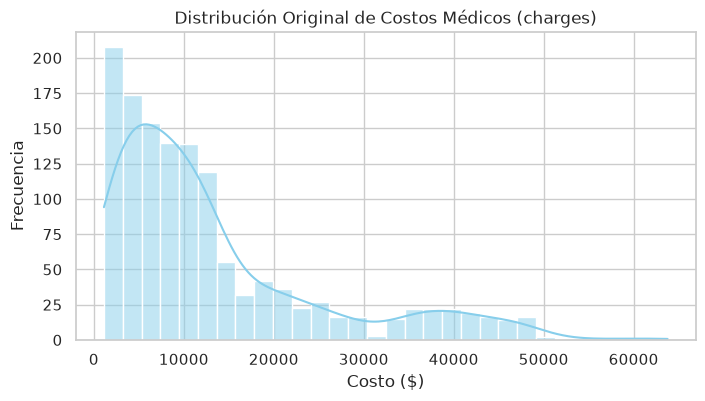

Sesgo original: 1.5158796580240388


In [16]:
# Gráfico de la variable objetivo original
plt.figure(figsize=(8, 4))
sns.histplot(df['charges'], kde=True, color='skyblue')
plt.title('Distribución Original de Costos Médicos (charges)')
plt.xlabel('Costo ($)')
plt.ylabel('Frecuencia')
plt.show()

# Ver la asimetría (skewness)
print("Sesgo original:", df['charges'].skew())

---
### Justificación de la Transformación Logarítmica en la Variable Objetivo

#### 1. Eliminación de la Asimetría Positiva (Right-Skewness)
La variable `charges` presenta una fuerte asimetría hacia la derecha: la mayoría de las personas tiene costos médicos bajos (entre \$2,000 y \$10,000), pero existe una minoría con costos muy elevados.

La regresión lineal asume que los errores se distribuyen de forma normal. Al aplicar $\log(y)$, se reducen las distancias en los valores altos y se expanden los bajos, acercando la distribución a una **campana de Gauss**.

#### 2. Control de Outliers y Varianza
Los costos médicos extremadamente altos actúan como *outliers* que pueden distorsionar la recta de regresión.

El logaritmo **estabiliza la varianza** (homocedasticidad) y reduce el impacto de estos valores atípicos sin necesidad de eliminar datos valiosos.

#### 3. Interpretación Porcentual
Con la transformación logarítmica en la variable dependiente, los coeficientes del modelo se interpretan como **cambios porcentuales** en el costo final ante cambios unitarios en las variables de entrada, lo cual es muy útil en análisis económicos y de seguros.

---

## 3. Aplicación de la transformación logarítmica

Se crea la columna `log_charges = log(charges)` y se comparan visualmente ambas distribuciones (original vs. logarítmica) junto con su *skew*, confirmando que la transformación reduce la asimetría.

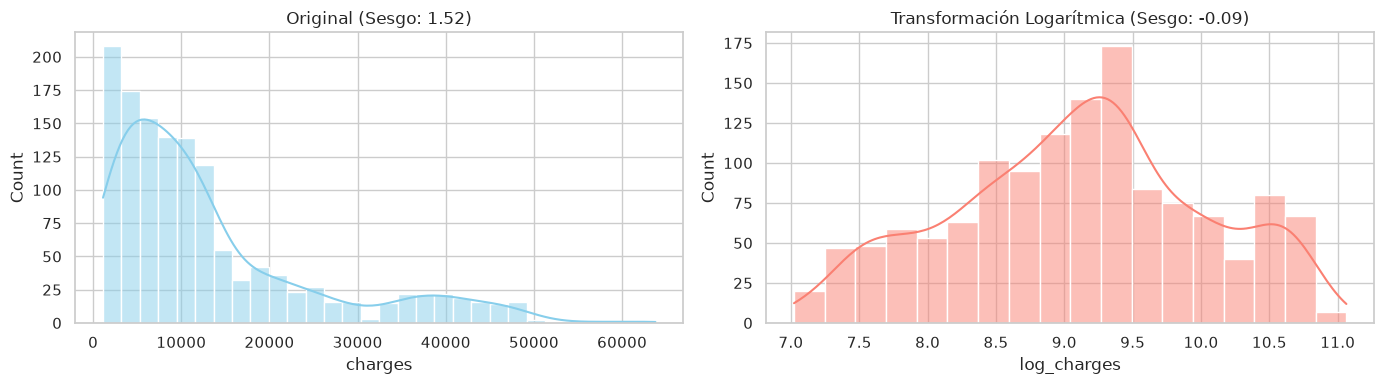

In [17]:
# Crear la nueva columna log_charges
df['log_charges'] = np.log(df['charges'])

# Graficar ambas lado a lado para comprobar el cambio
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['charges'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f'Original (Sesgo: {df["charges"].skew():.2f})')

sns.histplot(df['log_charges'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title(f'Transformación Logarítmica (Sesgo: {df["log_charges"].skew():.2f})')

plt.tight_layout()
plt.show()

## 4. Preprocesamiento: codificación de variables categóricas

Las columnas categóricas (`sex`, `smoker`, `region`) se convierten a variables dummy con `pd.get_dummies(drop_first=True)` para poder usarlas en el modelo lineal. Se separan las features (`X`) del target transformado (`y = log_charges`).

In [18]:
# Preprocesamiento: 
# Convertimos las variables categóricas a variables Dummy (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Separar variables independientes (X) y la variable objetivo transformada (y)
X = df_encoded.drop(columns=['charges', 'log_charges'])
y = df_encoded['log_charges']

## 5. División train/test y entrenamiento del modelo

Se separa el dataset en 80% entrenamiento / 20% prueba (`random_state=42` para reproducibilidad) y se entrena una `LinearRegression` sobre `log_charges`. Las predicciones (`y_pred_log`) quedan también en escala logarítmica.

In [19]:
# División 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear e instanciar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones en la escala logarítmica
y_pred_log = model.predict(X_test)

## 6. Evaluación en escala logarítmica

Se grafican los valores reales vs. predichos de `log(charges)`, con la línea diagonal como referencia de una predicción perfecta. Esto permite evaluar el ajuste del modelo en la escala en la que fue entrenado, antes de revertir la transformación.

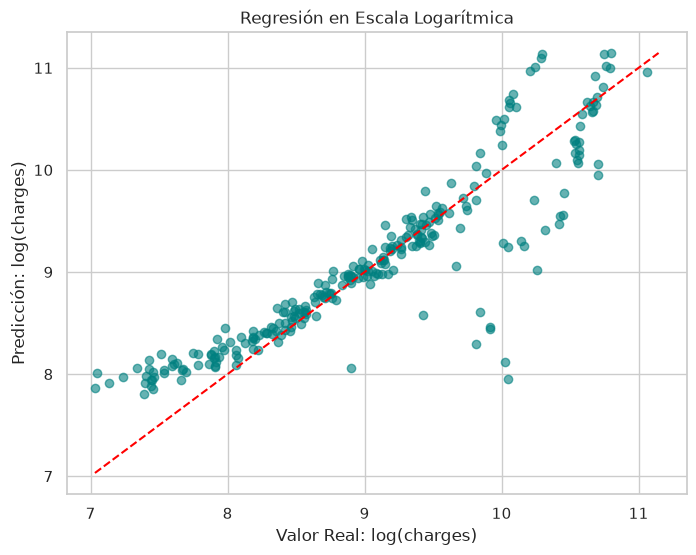

In [20]:
#Gráfica en escala logarítmica:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_log, alpha=0.6, color='teal')
max_val = max(y_test.max(), y_pred_log.max())
min_val = min(y_test.min(), y_pred_log.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.xlabel('Valor Real: log(charges)')
plt.ylabel('Predicción: log(charges)')
plt.title('Regresión en Escala Logarítmica')
plt.show()

## 7. Retransformación a dólares y métricas

Se aplica `np.exp()` para volver a la escala original de `charges` (dólares) tanto en los valores reales como en las predicciones, y se calculan **R²** y **RMSE** sobre esa escala, que es la que realmente le interesa al negocio.

In [21]:
# Revertir la transformación logarítmica para obtener valores en dólares
y_test_real = np.exp(y_test)
y_pred_real = np.exp(y_pred_log)

# Métricas de desempeño
r2 = r2_score(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f"R² Score (Varianza explicada): {r2:.4f}")
print(f"RMSE (Error cuadrático medio en USD): ${rmse:.2f}")

R² Score (Varianza explicada): 0.6066
RMSE (Error cuadrático medio en USD): $7815.31


## 8. Comparación visual en escala dólar

Se grafican los valores reales vs. predichos ya en dólares, con la línea de predicción perfecta (`y = x`) como referencia visual del ajuste.

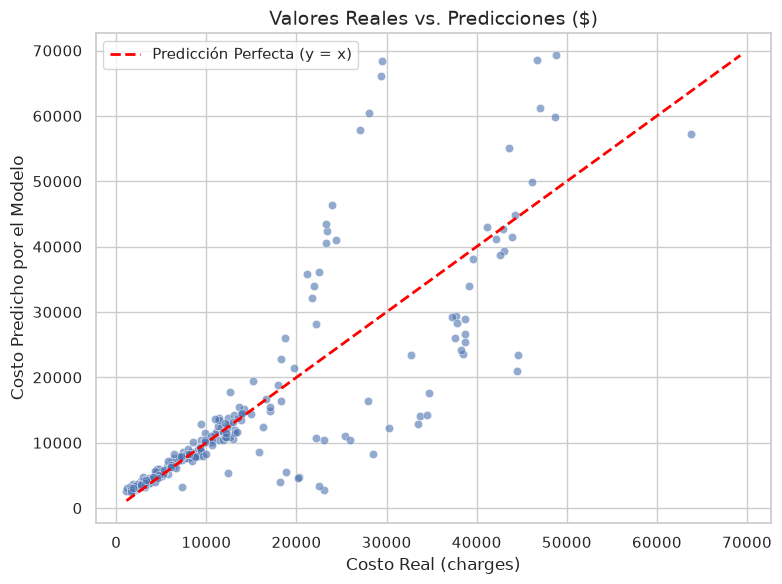

In [22]:
# Gráfico de Valores Reales vs. Predicciones con línea de ajuste ideal

plt.figure(figsize=(8, 6))

# Scatter plot entre los valores reales y las predicciones
sns.scatterplot(x=y_test_real, y=y_pred_real, alpha=0.6, color='b')

# Línea diagonal ideal (Predicción perfecta y = x)
max_val = max(y_test_real.max(), y_pred_real.max())
min_val = min(y_test_real.min(), y_pred_real.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y = x)')

plt.title('Valores Reales vs. Predicciones ($)', fontsize=14)
plt.xlabel('Costo Real (charges)', fontsize=12)
plt.ylabel('Costo Predicho por el Modelo', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

En escala logarítmica el modelo se ajusta adecuadamente (gráfica X); al retransformar a dólares se observa una subestimación en costos altos (gráfica Y), atribuible al sesgo de retransformación"